## Bibliotecas

In [ ]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
import spacy
import matplotlib.pyplot as plt
from collections import Counter
from itertools import chain
from wordcloud import WordCloud


In [ ]:
df = pd.read_csv('pre-processed.csv')

# Normalização

In [ ]:
df['preprocessed_news'] = df['preprocessed_news'].str.lower()

df.head()

,index,label,preprocessed_news
0,0,fake,katia abreu diz vai colocar expulsao moldura n...
1,1,fake,ray peita bolsonaro conservador fake entrevist...
2,2,fake,reinaldo azevedo desmascarado policia federal ...
3,3,fake,relatorio assustador bndes mostra dinheiro pub...
4,4,fake,radialista americano fala sobre pt vendem ilus...


In [ ]:
def tranformar_true_fake(label):
  if label == 'true':
    return 1
  else:
    return 0

df['label'] = df['label'].map(tranformar_true_fake)

df.head()

,index,label,preprocessed_news
0,0,0,katia abreu diz vai colocar expulsao moldura n...
1,1,0,ray peita bolsonaro conservador fake entrevist...
2,2,0,reinaldo azevedo desmascarado policia federal ...
3,3,0,relatorio assustador bndes mostra dinheiro pub...
4,4,0,radialista americano fala sobre pt vendem ilus...


# Tokenizar

In [ ]:
df['preprocessed_news'] = df['preprocessed_news'].str.split()

df.head()

,index,label,preprocessed_news
0,0,0,"[katia, abreu, diz, vai, colocar, expulsao, mo..."
1,1,0,"[ray, peita, bolsonaro, conservador, fake, ent..."
2,2,0,"[reinaldo, azevedo, desmascarado, policia, fed..."
3,3,0,"[relatorio, assustador, bndes, mostra, dinheir..."
4,4,0,"[radialista, americano, fala, sobre, pt, vende..."


# Remover palavras muito frequentes (preposições, conjuções, etc)


In [ ]:
nltk.download('stopwords')
stop_words = set(stopwords.words('portuguese'))

def remover_stop_words(text):
  return [word for word in text if word not in stop_words]

df['preprocessed_news'] = df['preprocessed_news'].apply(remover_stop_words)

df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,index,label,preprocessed_news
0,0,0,"[katia, abreu, diz, vai, colocar, expulsao, mo..."
1,1,0,"[ray, peita, bolsonaro, conservador, fake, ent..."
2,2,0,"[reinaldo, azevedo, desmascarado, policia, fed..."
3,3,0,"[relatorio, assustador, bndes, mostra, dinheir..."
4,4,0,"[radialista, americano, fala, sobre, pt, vende..."


# Radicalizar

In [ ]:
stemmer = SnowballStemmer('portuguese')

def stemizar(text):
  return [stemmer.stem(word) for word in text]

  df['preprocessed_news'] = df['preprocessed_news'].apply(stemizar)

df.head()

,index,label,preprocessed_news
0,0,0,"[katia, abreu, diz, vai, colocar, expulsao, mo..."
1,1,0,"[ray, peita, bolsonaro, conservador, fake, ent..."
2,2,0,"[reinaldo, azevedo, desmascarado, policia, fed..."
3,3,0,"[relatorio, assustador, bndes, mostra, dinheir..."
4,4,0,"[radialista, americano, fala, sobre, pt, vende..."


#Analisar o comprimento dos textos (número de palavras por documento).

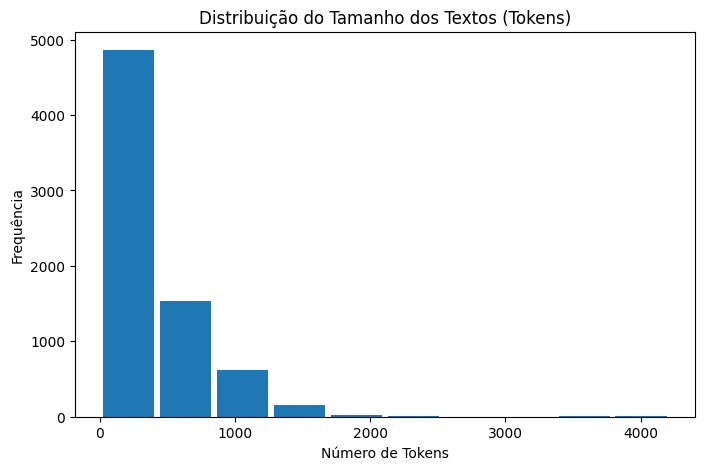

In [ ]:
df['preprocessed_news'].apply(len).hist(bins = 10, grid = False, figsize = (8,5), rwidth=0.9)
plt.title('Distribuição do Tamanho dos Textos (Tokens)')
plt.xlabel('Número de Tokens')
plt.ylabel('Frequência')
plt.show()

In [ ]:
#conta a quantidade de tokens
df['news_length'] = df['preprocessed_news'].apply(len)


#pega a media e mediana
media_tokens = df['news_length'].mean()
mediana_tokens = df['news_length'].median()

print(f"\nMédia do número de tokens por texto: {media_tokens:.2f}")
print(f"Mediana do número de tokens por texto: {mediana_tokens:.2f}")


Média do número de tokens por texto: 364.65
Mediana do número de tokens por texto: 209.00


# Palavras mais frequentes

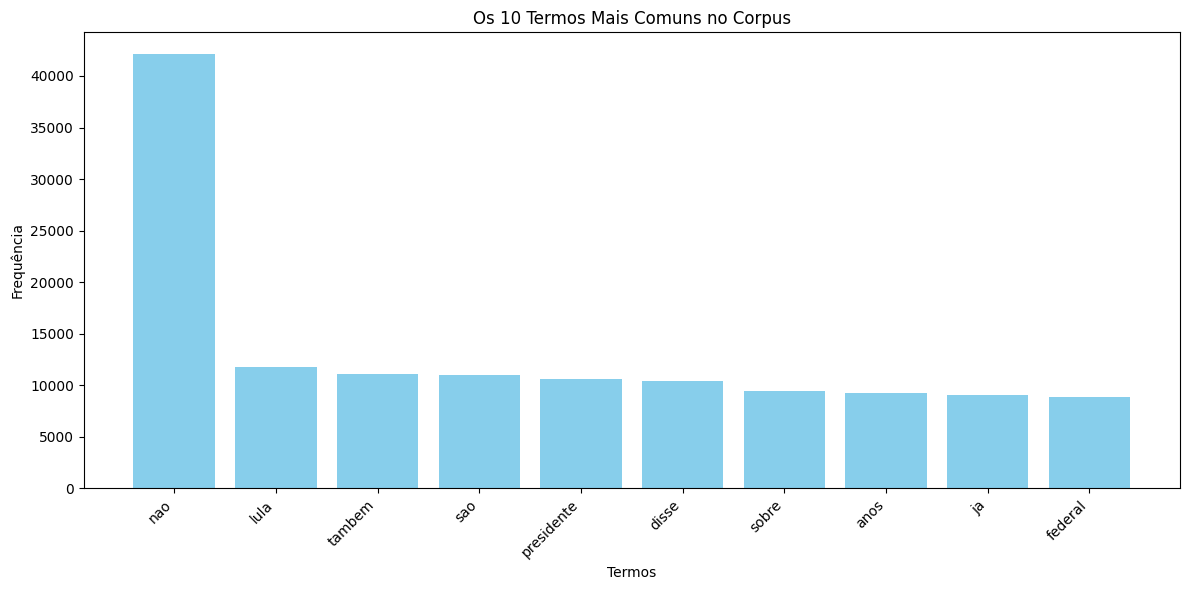

In [ ]:
#colocar todos os tokens em uma só ista
all_tokens = list(chain.from_iterable(df['preprocessed_news']))

# contar a frequencia de tokens
token_counts = Counter(all_tokens)

# pegar os 10 primeiros com as maiores frequência
most_common_terms = token_counts.most_common(10)

terms = [term for term, freq in most_common_terms]
counts = [freq for term, freq in most_common_terms]

plt.figure(figsize=(12, 6))
plt.bar(terms, counts, color='skyblue')
plt.xlabel('Termos')
plt.ylabel('Frequência')
plt.title('Os 10 Termos Mais Comuns no Corpus')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Frequência de palavras por classe

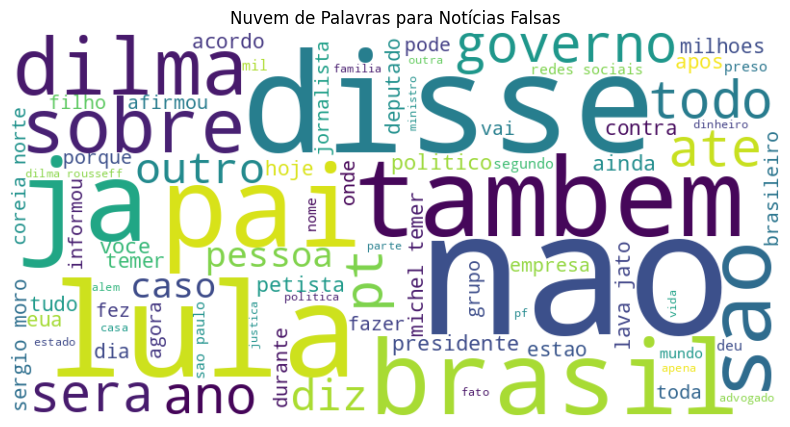

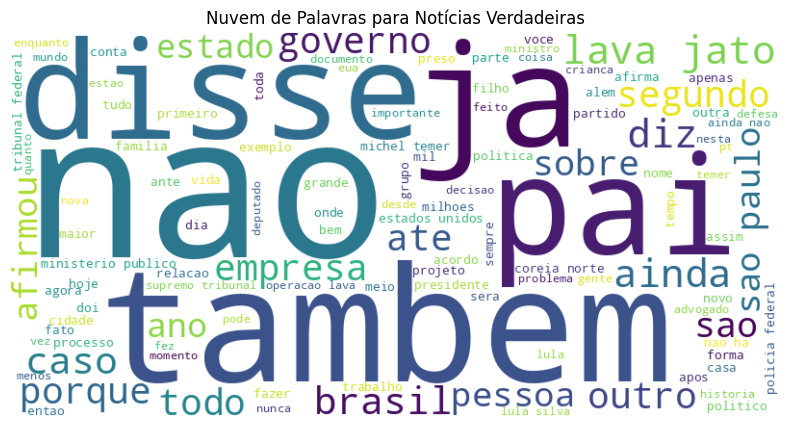

In [ ]:
# Separar o DataFrame com base no rótulo (fake=0, true=1)
df_fake = df[df['label'] == 0]
df_true = df[df['label'] == 1]

# Juntar todos os tokens de notícias falsas em uma única string
all_words_fake = ' '.join(list(chain.from_iterable(df_fake['preprocessed_news'])))

# Gerar a nuvem de palavras para notícias falsas
wordcloud_fake = WordCloud(width=800, height=400, background_color='white', min_font_size=10).generate(all_words_fake)

# Exibir a imagem gerada
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_fake, interpolation='bilinear')
plt.axis('off')
plt.title('Nuvem de Palavras para Notícias Falsas')
plt.show()

# Juntar todos os tokens de notícias verdadeiras em uma única string
all_words_true = ' '.join(list(chain.from_iterable(df_true['preprocessed_news'])))

# Gerar a nuvem de palavras para notícias verdadeiras
wordcloud_true = WordCloud(width=800, height=400, background_color='white', min_font_size=10).generate(all_words_true)

# Exibir a imagem gerada
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_true, interpolation='bilinear')
plt.axis('off')
plt.title('Nuvem de Palavras para Notícias Verdadeiras')
plt.show()